**This cell imports pandas, numpy, yfinance and matplotlib, brings in the helper functions from src/, and creates the data/raw and data/processed folders so that the download and save steps later in the notebook have somewhere to write to.**

In [19]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent)) # Add project root to sys.path so 'from src...' works when running from /notebooks

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import US_TICKERS, INDIA_TICKERS, PROCESSED_DATA_DIR, RAW_DATA_DIR
from src.data_utils import(
    download_prices,
    compute_returns,
    filter_tickers,
    build_portfolio,
    save_panel,
)

# Make sure the output directories exist before any download or save call
RAW_DATA_DIR.mkdir(parents = True, exist_ok = True)
PROCESSED_DATA_DIR.mkdir(parents = True, exist_ok = True)

**This cell downloads daily adjusted close prices from Yahoo Finance for both ticker lists over the full sample window. The shape and head printout at the end is a quick sanity check to make sure the data is correct.**

In [14]:
us_close = download_prices(US_TICKERS) # DataFrame: dates x US tickers, adjusted close
india_close = download_prices(INDIA_TICKERS)  # DataFrame: dates x India tickers, adjusted close

# Check the data
print(f"US prices: {us_close.shape}")
print(us_close.head())
print(f"India prices: {india_close.shape}")
print(india_close.head())

US prices: (4024, 30)
Ticker          AAPL         BA        BAC          C        CAT        COP  \
Date                                                                          
2010-01-04  6.412383  43.777557  12.100781  24.979115  39.124390  22.791386   
2010-01-05  6.423470  45.211338  12.494111  25.934208  39.592148  22.813059   
2010-01-06  6.321296  46.582809  12.640647  26.742350  39.712414  22.977772   
2010-01-07  6.309609  48.468555  13.057117  26.815817  39.872791  22.886742   
2010-01-08  6.351560  48.001019  12.941437  26.375011  40.320507  23.086138   

Ticker           CSCO        CVX        DIS         GE  ...        MRK  \
Date                                                    ...              
2010-01-04  15.889598  41.265438  27.291227  53.524780  ...  20.460764   
2010-01-05  15.818808  41.557735  27.223148  53.801949  ...  20.543695   
2010-01-06  15.715832  41.562962  27.078478  53.524780  ...  20.820103   
2010-01-07  15.786628  41.406372  27.086990  56.296299

**This cell turns the price panels into daily log returns and drops any ticker that does not have enough history to be useful. 
The result is two clean return panels, one per market, ready to be aggregated into portfolios.**

In [15]:
# compute_returns: Log returns r_t = ln(P_t / P_{t-1})
# filter_tickers: Drop columns failing the min-history threshold

us_returns = filter_tickers(compute_returns(us_close))
india_returns = filter_tickers(compute_returns(india_close))

print(f"US returns: {us_returns.shape}")
print(f"India returns: {india_returns.shape}")

US returns: (4023, 30)
India returns: (3949, 30)


**This cell turns each return panel into a single daily portfolio return series by taking the cross-sectional mean of returns each day. The result is one number per date for each market.**

In [16]:
# build_portfolio: cross-sectional mean of returns per date -> 1/N equal-weighted, rebalanced daily

us_portfolio = build_portfolio(us_returns)
india_portfolio = build_portfolio(india_returns)

print(f"US portfolio: {len(us_portfolio)} days")
print(f"India portfolio: {len(india_portfolio)} days")

US portfolio: 4023 days
India portfolio: 3949 days


**This cell sanity-checks the two portfolios before I move onto modelling. It prints annualised mean and volatility, skew, excess kurtosis, the worst and best single days, and the sample size for each market. Then plots cumulative returns side by side so I can visually compare the two markets over the full window.**

                      US      India
Annual return     0.1137     0.1496
Annual vol        0.1676     0.1503
Skew             -0.7196    -1.0126
Kurtosis         18.1766    14.2986
Min daily        -0.1268    -0.1267
Max daily         0.1037     0.0808
N obs          4023.0000  3949.0000


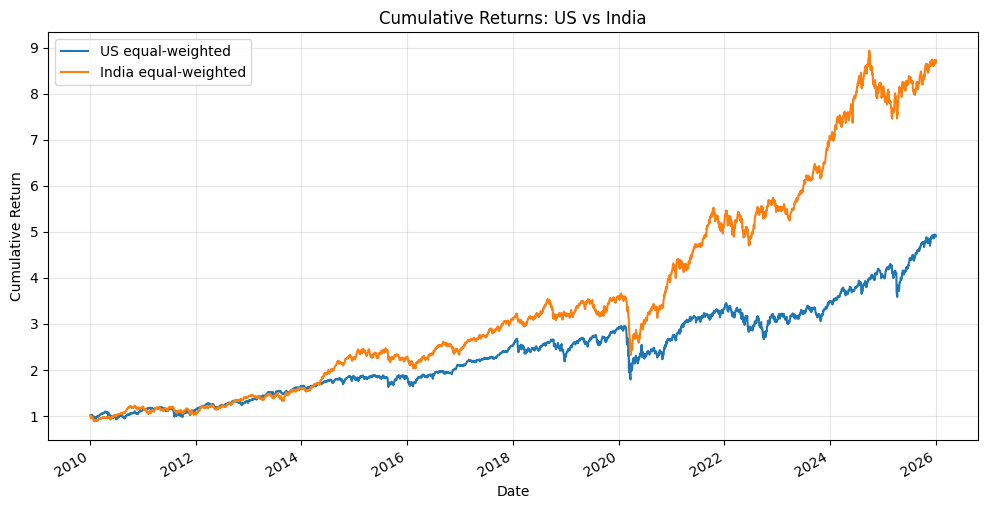

In [17]:
# Build a side-by-side stats table
stats = pd.DataFrame({
    "US": [us_portfolio.mean() * 252, us_portfolio.std() * np.sqrt(252),
           us_portfolio.skew(), us_portfolio.kurtosis(),
           us_portfolio.min(), us_portfolio.max(), len(us_portfolio)],
    
    "India": [india_portfolio.mean() * 252, india_portfolio.std() * np.sqrt(252),
              india_portfolio.skew(), india_portfolio.kurtosis(),
              india_portfolio.min(), india_portfolio.max(), len(india_portfolio)],
    
}, index = ["Annual return", "Annual vol", "Skew", "Kurtosis", "Min daily", "Max daily", "N obs"])

print(stats.round(4))

# Culumative-return chart
fig, ax = plt.subplots(figsize = (12,6))
(1 + us_portfolio).cumprod().plot(ax = ax, label = "US equal-weighted")
(1+ india_portfolio).cumprod().plot(ax = ax, label = "India equal-weighted")

ax.legend()
ax.set_title("Cumulative Returns: US vs India")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.grid(alpha = 0.3)
plt.show()

**This cell writes the per-ticker return panels and the portfolio return series to data/processed/ as Parquet. Notebooks 02 to 06 will start by reading these files, so this step is what makes the rest of the pipeline possible.**

In [18]:
# Save data into parquet files

save_panel(us_returns, PROCESSED_DATA_DIR / "us_returns.parquet")
save_panel(india_returns, PROCESSED_DATA_DIR / "india_returns.parquet")
save_panel(us_portfolio.to_frame(), PROCESSED_DATA_DIR / "us_portfolio.parquet")
save_panel(india_portfolio.to_frame(), PROCESSED_DATA_DIR / "india_portfolio.parquet")

print("Parquets saved successfully!")

Parquets saved successfully!


## Output files

- us_returns.parquet - Daily log returns, dates × tickers (US)
- india_returns.parquet - Daily log returns, dates × tickers (India)
- us_portfolio.parquet - Daily equal-weighted portfolio return (US)
- india_portfolio.parquet - Daily equal-weighted portfolio return (India)

All returns are log returns (close-to-close). Portfolio returns are cross-sectional means with daily rebalancing.